#### plot percent reductions

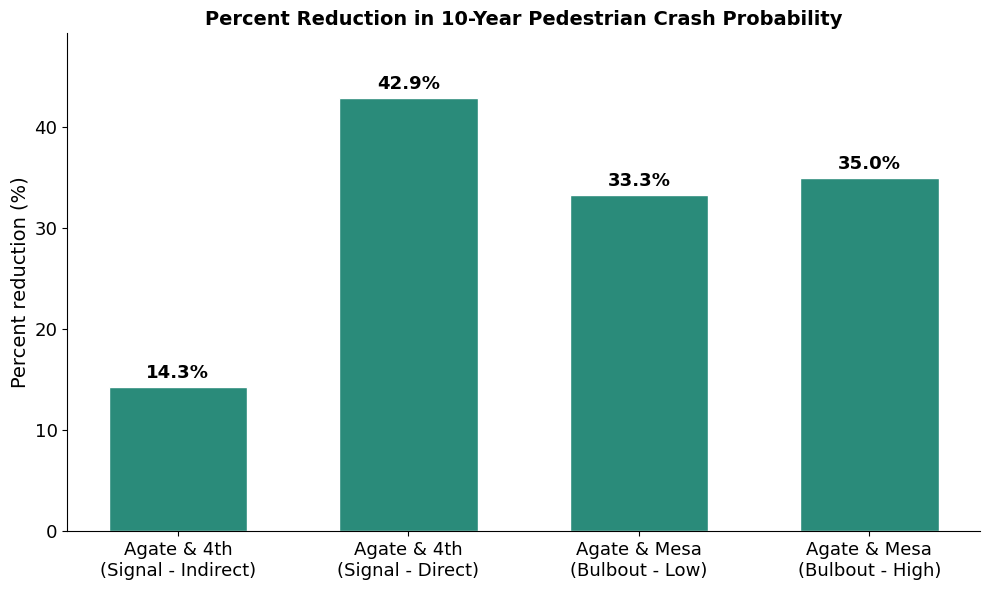

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

comparisons = {
    "Agate & 4th\n(Signal - Indirect)": (28, 24),
    "Agate & 4th\n(Signal - Direct)":   (28, 16),
    "Agate & Mesa\n(Bulbout - Low)":    (15, 10),
    "Agate & Mesa\n(Bulbout - High)":   (20, 13),
}

# calculate percent reduction
def pct_reduction(before, after):
    return ((before - after) / before) * 100

labels = list(comparisons.keys())
reductions = [pct_reduction(b, a) for b, a in comparisons.values()]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, reductions, color="#2A8B7A", edgecolor="white", width=0.6)

# annotate bars
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f"{h:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=13)

ax.set_ylabel("Percent reduction (%)", fontsize=14)
ax.set_title("Percent Reduction in 10-Year Pedestrian Crash Probability",
             fontsize=14, fontweight="bold")
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(reductions) * 1.15)

plt.tight_layout()
plt.show()

#### Plot before and after 10 year probabalities for each scenario

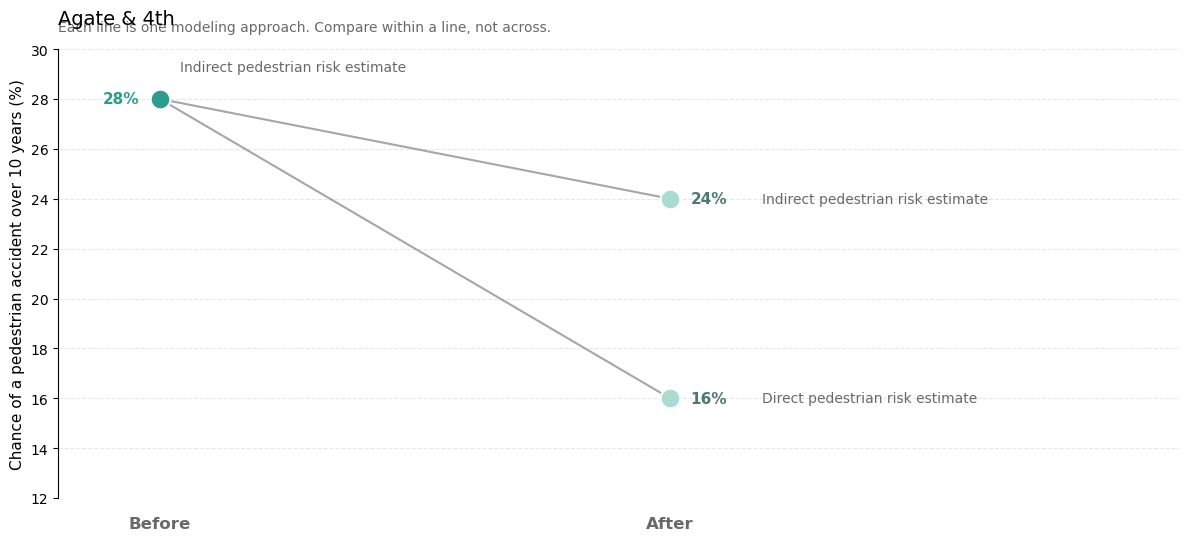

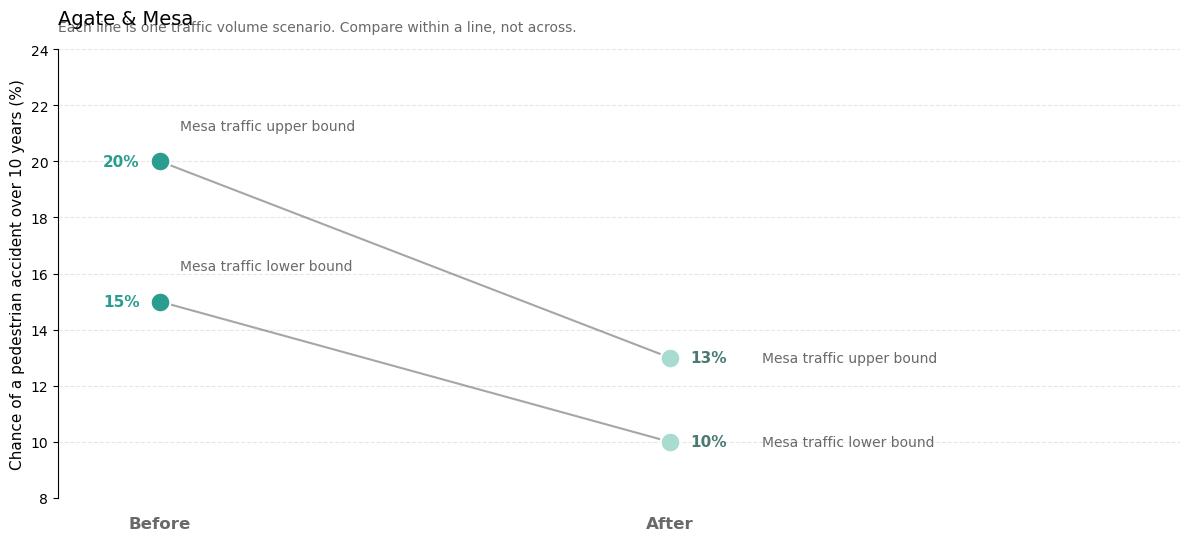

In [ ]:
import matplotlib.pyplot as plt

before_color = "#2A9D8F"
after_color  = "#A8DCD1"
after_text   = "#4a7a73"

def plot_scenarios(intersection_name, scenarios, subtitle, ylim):
    """
    scenarios: list of (label, before, after) tuples
    ylim: (y_min, y_max) for the y-axis
    """
    y_min, y_max = ylim

    fig, ax = plt.subplots(figsize=(12, 5.5))

    # Track which Before values already have a label (to avoid duplicates
    # when multiple scenarios share the same Before point).
    labeled_befores = set()

    for label, before, after in scenarios:
        # Connecting line
        ax.plot([0, 1], [before, after], color="gray", linewidth=1.5,
                zorder=1, alpha=0.7)
        # Before dot
        ax.scatter(0, before, s=200, color=before_color,
                   zorder=3, edgecolor="white", linewidth=1.5)
        # After dot
        ax.scatter(1, after, s=200, color=after_color,
                   zorder=3, edgecolor="white", linewidth=1.5)

        # Before value label (just left of the dot)
        if before not in labeled_befores:
            ax.text(-0.04, before, f"{before}%", ha="right", va="center",
                    fontsize=11, color=before_color, fontweight="bold")
            # Scenario label above-and-right of the Before dot
            ax.text(0.04, before + 1, label, ha="left", va="bottom",
                    fontsize=10, color="dimgray")
            labeled_befores.add(before)

        # After value label (just right of the dot)
        ax.text(1.04, after, f"{after}%", ha="left", va="center",
                fontsize=11, color=after_text, fontweight="bold")
        # Scenario label to the right of the After dot
        ax.text(1.18, after, label, ha="left", va="center",
                fontsize=10, color="dimgray")

    # "Before" and "After" headers at the BOTTOM of the plot
    header_y = y_min - (y_max - y_min) * 0.04
    ax.text(0, header_y, "Before", ha="center", va="top",
            fontsize=12, color="dimgray", fontweight="bold")
    ax.text(1, header_y, "After", ha="center", va="top",
            fontsize=12, color="dimgray", fontweight="bold")

    ax.set_xticks([])
    ax.set_xlim(-0.2, 2.0)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel("Chance of a pedestrian accident over 10 years (%)",
                  fontsize=11)
    ax.set_title(intersection_name, fontsize=14, loc="left", pad=18)
    ax.text(0, 1.04, subtitle, transform=ax.transAxes,
            fontsize=10, color="dimgray")
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    plt.subplots_adjust(bottom=0.15)
    plt.tight_layout()
    plt.show()


# Agate & 4th
scenarios_4th = [
    ("Indirect pedestrian risk estimate", 28, 24),
    ("Direct pedestrian risk estimate",   28, 16),
]
plot_scenarios(
    "Agate & 4th",
    scenarios_4th,
    "Each line is one modeling approach. Compare within a line, not across.",
    ylim=(12, 30),
)


# Agate & Mesa
scenarios_mesa = [
    ("Mesa traffic lower bound", 15, 10),
    ("Mesa traffic upper bound", 20, 13),
]
plot_scenarios(
    "Agate & Mesa",
    scenarios_mesa,
    "Each line is one traffic volume scenario. Compare within a line, not across.",
    ylim=(8, 24),
)

#### "Sensitivity analysis" for different mesa traffic volumes

In [ ]:
# first check if the calculations work and produce same results as brady

import math

def estimate_3st_ped_risk(
    aadt_maj,
    aadt_min,
    cmf_lighting=0.91,
    cmf_curb_extension=0.63,
    cmf_twltl=0.92,
):
    """Pedestrian crash risk at a 3ST intersection, following the slide."""
    # Step 1: multi-vehicle crashes
    n_bimv = math.exp(-13.36 + 1.11 * math.log(aadt_maj) + 0.41 * math.log(aadt_min))

    # Step 2: single-vehicle crashes
    n_bisv = math.exp(-6.81 + 0.16 * math.log(aadt_maj) + 0.51 * math.log(aadt_min))

    # Step 3: combine and apply CMFs
    n_bi = (n_bimv + n_bisv) * cmf_lighting * cmf_curb_extension * cmf_twltl

    # Step 4: pedestrian crashes as 2.1% of vehicle crashes
    n_pedi = n_bi * 0.021

    return {"n_bimv": n_bimv, "n_bisv": n_bisv, "n_bi": n_bi, "n_pedi": n_pedi}


r = estimate_3st_ped_risk(aadt_maj=11000, aadt_min=1000)
for k, v in r.items():
    print(f"{k}: {v:.4f}")

n_bimv: 0.8199
n_bisv: 0.1656
n_bi: 0.5198
n_pedi: 0.0109


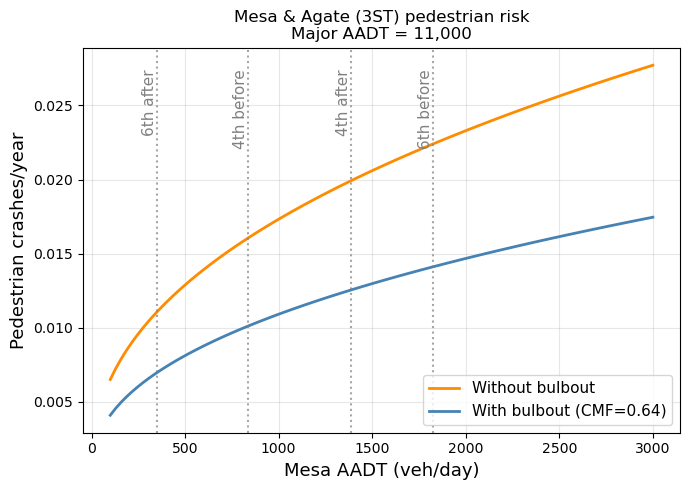

In [ ]:
import matplotlib.pyplot as plt
import math
import numpy as np


def ped_crashes_3st(aadt_maj, aadt_min, cmf_extra=1.0):
    """Pedestrian crashes/year at a 3ST, with optional extra CMF (e.g., bulbout)."""
    n_bimv = math.exp(-13.36 + 1.11 * math.log(aadt_maj) + 0.41 * math.log(aadt_min))
    n_bisv = math.exp(-6.81 + 0.16 * math.log(aadt_maj) + 0.51 * math.log(aadt_min))
    cmf_lighting = 0.91
    cmf_twltl = 0.92
    n_bi = (n_bimv + n_bisv) * cmf_lighting * cmf_twltl * cmf_extra
    return n_bi * 0.021


# AADTs based on SGM minor/major ratios
references = {
    "4th before":  11000 * 0.076,
    "4th after":   11000 * 0.126,
    "6th before":  11000 * 0.166,
    "6th after":   11000 * 0.032,
}

aadt_min_range = np.linspace(100, 3000, 100)
AADT_MAJ = 11000

ped_no_bulbout = [ped_crashes_3st(AADT_MAJ, x, cmf_extra=1.0) for x in aadt_min_range]
ped_bulbout    = [ped_crashes_3st(AADT_MAJ, x, cmf_extra=0.63) for x in aadt_min_range]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(aadt_min_range, ped_no_bulbout, color="darkorange", linewidth=2, label="Without bulbout")
ax.plot(aadt_min_range, ped_bulbout, color="steelblue", linewidth=2, label="With bulbout (CMF=0.64)")

for label, x in references.items():
    ax.axvline(x, color="gray", linestyle=":", alpha=0.7)
    ax.text(x, ax.get_ylim()[1] * 0.95, label, rotation=90,
            verticalalignment="top", horizontalalignment="right",
            fontsize=11, color="gray")

ax.set_xlabel("Mesa AADT (veh/day)", fontsize=13)
ax.set_ylabel("Pedestrian crashes/year", fontsize=13)
ax.set_title(f"Mesa & Agate (3ST) pedestrian risk\nMajor AADT = {AADT_MAJ:,}")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()